**Problem 4** - SPORTS or POLITICS

You have to design a classifier that reads a text document and classify it as Sport or Politics
using any of your favorite machine learning techniques. For feature representation you can
use: n-grams, TF-IDF, Bag of Words. You should compare atleast three ML Techniques for
this task. Write a detailed report (minimum 5 page) starting from how did you collected data
for this task, your dataset description and anlysis, techniques in brief and their quantative
comparisions, limitations of your system.

---

**Importing the Dataset from Kaggle**

---> Using the *kagglehub* library for importing the latest version of the dataset.

In [84]:
import kagglehub

# Download latest version of the dataset
path = kagglehub.dataset_download("setseries/news-category-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'news-category-dataset' dataset.
Path to dataset files: /kaggle/input/news-category-dataset


**Importing all the necessary libraries required**

In [85]:
# Pandas for Processing the Dataset
import pandas as pd

# "re" for basic text cleaning tasks
import re

# Importing NLP Frameworks for feature engineering
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# "sklearn" for ML Tasks - Splitting , Running Models and Analysing the Results
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB # Multinomial Naive Bayes
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC # Linear SVM
from sklearn.metrics import classification_report, accuracy_score # For generating Reports
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Libraries for Plotting Curves
import matplotlib.pyplot as plt
import seaborn as sns

# For Creating Word Cloud
from wordcloud import WordCloud

# Numpy for Calculations
import numpy as np

**Using Pandas to load the dataset in a DataFrame**

*   Reading the CSV File.
*   Checking the Shape and the Number of Columns in the dataset.
*   Checking the different Category Labels in the Dataset.


In [86]:

df = pd.read_csv("/root/.cache/kagglehub/datasets/setseries/NewsCategorizer.csv")

print(df.shape)
print(df.columns)
print(df["category"].value_counts())


(50000, 5)
Index(['category', 'headline', 'links', 'short_description', 'keywords'], dtype='object')
category
WELLNESS          5000
POLITICS          5000
ENTERTAINMENT     5000
TRAVEL            5000
STYLE & BEAUTY    5000
PARENTING         5000
FOOD & DRINK      5000
WORLD NEWS        5000
BUSINESS          5000
SPORTS            5000
Name: count, dtype: int64


**The Dataset contains 10 Labels** - Our Labels for Interest are **POLITICS** and **SPORTS**. We will filter out those labels from the dataframe using **isin** operation.

In [87]:
filtered_df = df[df["category"].isin(["POLITICS", "SPORTS"])]

print(filtered_df.shape)
print(filtered_df["category"].value_counts())

(10000, 5)
category
POLITICS    5000
SPORTS      5000
Name: count, dtype: int64


**Resetting the Indices and saving this new dataframe as a CSV**

In [88]:
filtered_df = filtered_df.reset_index(drop=True)
filtered_df.to_csv("sports_vs_politics.csv", index=False)

**Creating Numeric Labels for POLITICS and SPORTS**

*   0 - POLITICS
*   1 - SPORTS

In [89]:
label_map = {"POLITICS": 0, "SPORTS": 1}
filtered_df["label"] = filtered_df["category"].map(label_map)

print(filtered_df[["category", "label"]].head())


   category  label
0  POLITICS      0
1  POLITICS      0
2  POLITICS      0
3  POLITICS      0
4  POLITICS      0


**Visualizing the Class Distribution**

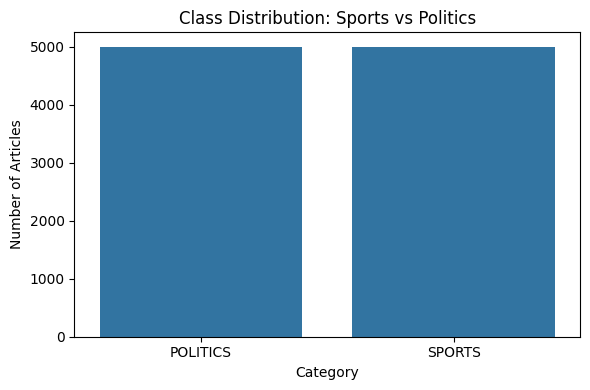

In [90]:
plt.figure(figsize=(6,4))
sns.countplot(data=filtered_df, x="category")
plt.title("Class Distribution: Sports vs Politics")
plt.xlabel("Category")
plt.ylabel("Number of Articles")
plt.tight_layout()
plt.show()

**Luckily, there are equal number of samples from every class**

Looking at the Dataset - the most useful features for us are **headline** and **short_description**. We can combine them into **one single text field**.

In [91]:
filtered_df["text"] = (
    filtered_df["headline"].fillna("") + " " +
    filtered_df["short_description"].fillna("")
)

filtered_df[["headline", "short_description", "text"]].head()


,headline,short_description,text
0,GOP Congressman Suggests Looser Standard Of Pr...,"Rep. Lee Zeldin says there needs to be ""some t...",GOP Congressman Suggests Looser Standard Of Pr...
1,The ACLU Is Suing To Strike Down Ohio's Congre...,The civil liberties group says Ohio's map is s...,The ACLU Is Suing To Strike Down Ohio's Congre...
2,Don't Like The New Climate Rules? Thank Congress.,Legislators could have passed a climate change...,Don't Like The New Climate Rules? Thank Congre...
3,The Story Behind An Iconic Picture Of Civil Ri...,An often-forgotten battle for free speech righ...,The Story Behind An Iconic Picture Of Civil Ri...
4,Pro-Abortion Rights Progressive Wins Nebraska ...,Kara Eastman prevailed against an establishmen...,Pro-Abortion Rights Progressive Wins Nebraska ...


**Performing a Basic Cleaning using RegeX**

*   Lowercasing
*   Removal of Punctuation Marks
*   Removing Numbers
*   Removing Extra Spaces


In [92]:
def clean_text(text):
    text = text.lower() # Lowercasing
    text = re.sub(r"http\S+|www\S+", "", text)   # remove URLs
    text = re.sub(r"[^a-z\s]", " ", text)        # keep only letters
    text = re.sub(r"\s+", " ", text).strip()     # remove extra spaces
    return text

filtered_df["clean_text"] = filtered_df["text"].apply(clean_text)


**Document Length Distribution - Words per Article**

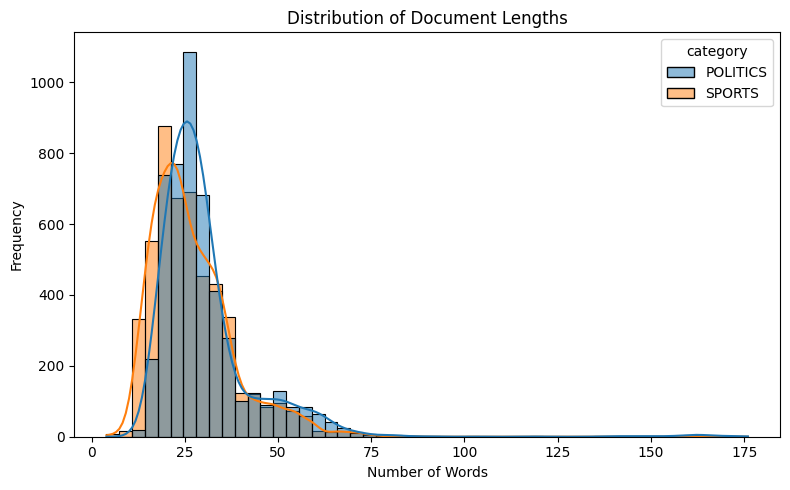

In [93]:
filtered_df["doc_length"] = filtered_df["clean_text"].apply(lambda x: len(x.split()))

plt.figure(figsize=(8,5))
sns.histplot(data=filtered_df, x="doc_length", hue="category", bins=50, kde=True)
plt.title("Distribution of Document Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


**Top 20 Most Frequent Words per class**

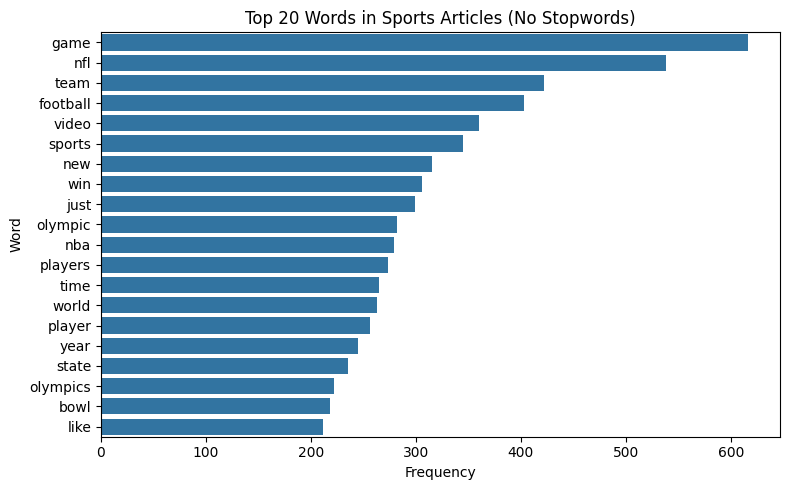

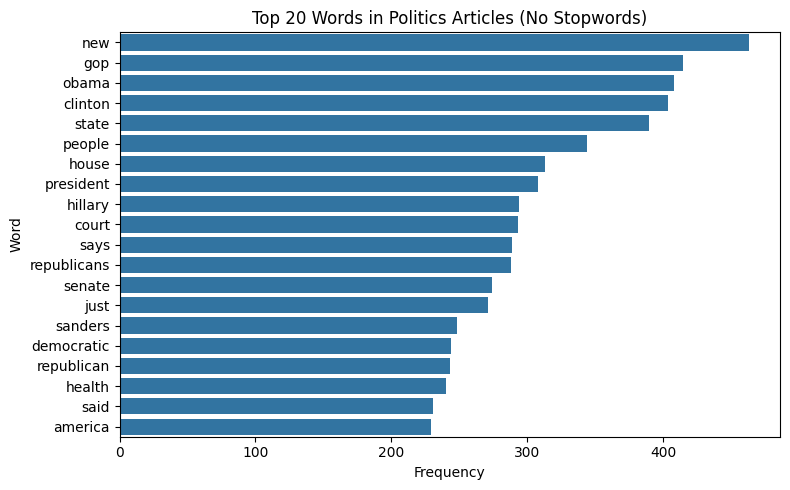

In [94]:
stopwords = set(ENGLISH_STOP_WORDS)

def top_words_by_class(df, category, n=20):
    text = " ".join(df[df["category"] == category]["clean_text"])
    words = text.split()

    # Remove stopwords and very short words
    words = [w for w in words if w not in stopwords and len(w) > 2]

    counter = Counter(words)
    return counter.most_common(n)

sports_words = top_words_by_class(filtered_df, "SPORTS", 20)
politics_words = top_words_by_class(filtered_df, "POLITICS", 20)

# Sports
words, counts = zip(*sports_words)
plt.figure(figsize=(8,5))
sns.barplot(x=list(counts), y=list(words))
plt.title("Top 20 Words in Sports Articles (No Stopwords)")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.tight_layout()
plt.show()

# Politics
words, counts = zip(*politics_words)
plt.figure(figsize=(8,5))
sns.barplot(x=list(counts), y=list(words))
plt.title("Top 20 Words in Politics Articles (No Stopwords)")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.tight_layout()
plt.show()


**Word Clouds for Sports v/s Politics**

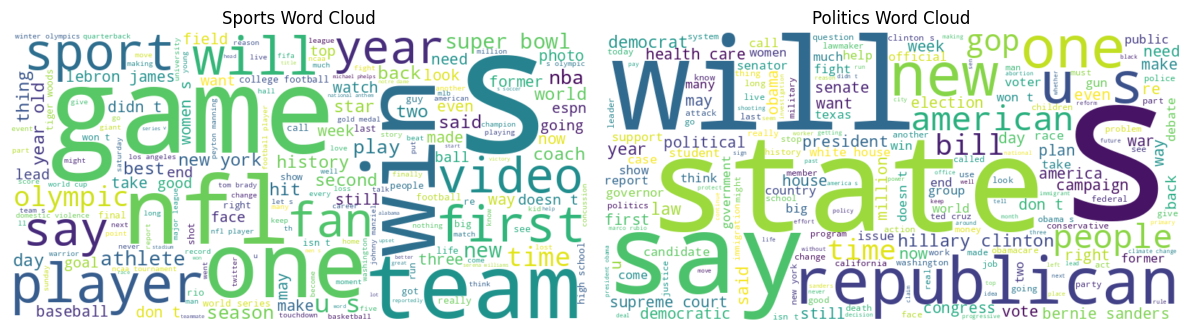

In [95]:
sports_text = " ".join(filtered_df[filtered_df["category"] == "SPORTS"]["clean_text"])
politics_text = " ".join(filtered_df[filtered_df["category"] == "POLITICS"]["clean_text"])

wc_sports = WordCloud(width=800, height=400, background_color="white").generate(sports_text)
wc_politics = WordCloud(width=800, height=400, background_color="white").generate(politics_text)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(wc_sports, interpolation="bilinear")
plt.axis("off")
plt.title("Sports Word Cloud")

plt.subplot(1,2,2)
plt.imshow(wc_politics, interpolation="bilinear")
plt.axis("off")
plt.title("Politics Word Cloud")

plt.tight_layout()
plt.show()


**Creating the Train-Test Split** - 80% goes to Training and the rest 20% for testing

In [96]:
X = filtered_df["clean_text"]
y = filtered_df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))


Train size: 8000
Test size: 2000


**Feature Extraction using BoW , TF-IDF and N-Grams**

In [97]:
bow_vectorizer = CountVectorizer(
    stop_words="english",
    max_features=10000
)

X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

print("BoW shape:", X_train_bow.shape)

BoW shape: (8000, 10000)


In [98]:

tfidf_vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=10000
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("TF-IDF shape:", X_train_tfidf.shape)


TF-IDF shape: (8000, 10000)


In [99]:
tfidf_ngram_vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=15000,
    ngram_range=(1, 2)
)

X_train_tfidf_ng = tfidf_ngram_vectorizer.fit_transform(X_train)
X_test_tfidf_ng = tfidf_ngram_vectorizer.transform(X_test)

print("TF-IDF ngram shape:", X_train_tfidf_ng.shape)


TF-IDF ngram shape: (8000, 15000)


**Comparing the Vocabulary Size for the three feature representation Techniques**

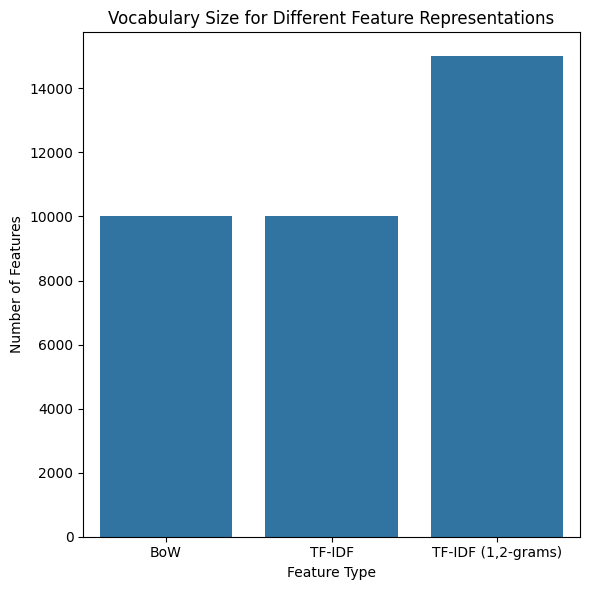

In [100]:
bow_vocab_size = len(bow_vectorizer.get_feature_names_out())
tfidf_vocab_size = len(tfidf_vectorizer.get_feature_names_out())
tfidf_ng_vocab_size = len(tfidf_ngram_vectorizer.get_feature_names_out())

features = ["BoW", "TF-IDF", "TF-IDF (1,2-grams)"]
sizes = [bow_vocab_size, tfidf_vocab_size, tfidf_ng_vocab_size]

plt.figure(figsize=(6,6))
sns.barplot(x=features, y=sizes)
plt.title("Vocabulary Size for Different Feature Representations")
plt.ylabel("Number of Features")
plt.xlabel("Feature Type")
plt.tight_layout()
plt.show()


**Top TF-IDF Features Per Class**

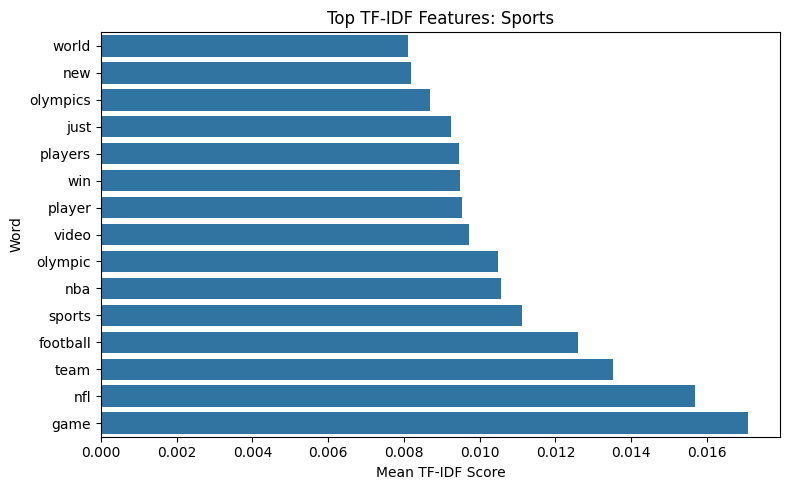

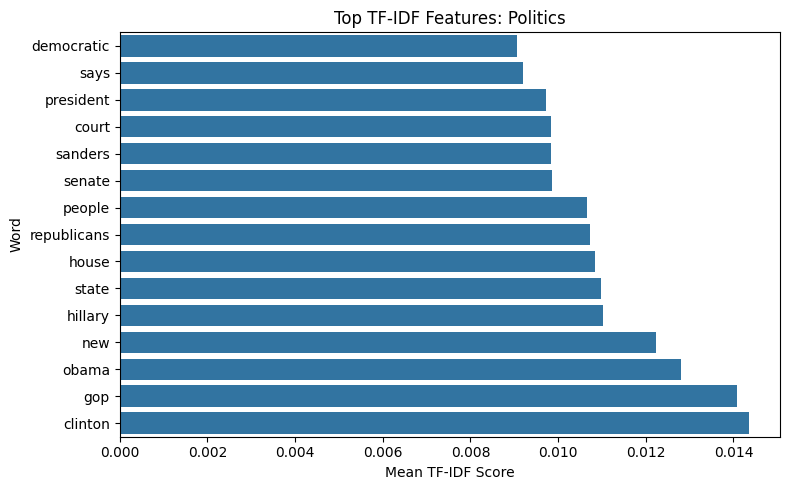

In [101]:
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())

X_tfidf_all = tfidf_vectorizer.transform(filtered_df["clean_text"])
y_all = filtered_df["label"].values

# Mean TF-IDF per class
mean_tfidf_sports = X_tfidf_all[y_all == 1].mean(axis=0).A1
mean_tfidf_politics = X_tfidf_all[y_all == 0].mean(axis=0).A1

top_sports_idx = np.argsort(mean_tfidf_sports)[-15:]
top_politics_idx = np.argsort(mean_tfidf_politics)[-15:]

# Plot Sports
plt.figure(figsize=(8,5))
sns.barplot(x=mean_tfidf_sports[top_sports_idx], y=feature_names[top_sports_idx])
plt.title("Top TF-IDF Features: Sports")
plt.xlabel("Mean TF-IDF Score")
plt.ylabel("Word")
plt.tight_layout()
plt.show()

# Plot Politics
plt.figure(figsize=(8,5))
sns.barplot(x=mean_tfidf_politics[top_politics_idx], y=feature_names[top_politics_idx])
plt.title("Top TF-IDF Features: Politics")
plt.xlabel("Mean TF-IDF Score")
plt.ylabel("Word")
plt.tight_layout()
plt.show()


**Training the Models**

In [102]:
def train_and_evaluate(model, X_train, X_test, y_train, y_test, name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n===== {name} =====")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))


**Instantiating the Models**

1.   Multinomial Naive Bayes
2.   Logistic Regression
3.   Linear SVM
4.   Random Forest
5.   KNN with 5 Neighbours


In [103]:
nb = MultinomialNB()
lr = LogisticRegression(max_iter=1000) # Setting a max_iteration so that the gradient descent doesnt go up for an infinite time
svm = LinearSVC()
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
knn = KNeighborsClassifier(n_neighbors=5)



**Evaluating the Model on BoW Feature Representations**

In [104]:
train_and_evaluate(nb, X_train_bow, X_test_bow, y_train, y_test, "NB + BoW")
train_and_evaluate(lr, X_train_bow, X_test_bow, y_train, y_test, "LR + BoW")
train_and_evaluate(svm, X_train_bow, X_test_bow, y_train, y_test, "SVM + BoW")
train_and_evaluate(knn, X_train_bow, X_test_bow, y_train, y_test, "KNN + BoW")
train_and_evaluate(rf, X_train_bow, X_test_bow, y_train, y_test, "RF + BoW")


===== NB + BoW =====
Accuracy: 0.9795
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1000
           1       0.98      0.98      0.98      1000

    accuracy                           0.98      2000
   macro avg       0.98      0.98      0.98      2000
weighted avg       0.98      0.98      0.98      2000


===== LR + BoW =====
Accuracy: 0.982
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1000
           1       0.97      0.99      0.98      1000

    accuracy                           0.98      2000
   macro avg       0.98      0.98      0.98      2000
weighted avg       0.98      0.98      0.98      2000


===== SVM + BoW =====
Accuracy: 0.974
              precision    recall  f1-score   support

           0       0.98      0.97      0.97      1000
           1       0.97      0.98      0.97      1000

    accuracy                           0.97      2000
   macro avg

**Evaluating the Models on TF-IDF Feature Representations**

In [105]:
train_and_evaluate(nb, X_train_tfidf, X_test_tfidf, y_train, y_test, "NB + TF-IDF")
train_and_evaluate(lr, X_train_tfidf, X_test_tfidf, y_train, y_test, "LR + TF-IDF")
train_and_evaluate(svm, X_train_tfidf, X_test_tfidf, y_train, y_test, "SVM + TF-IDF")
train_and_evaluate(knn, X_train_tfidf, X_test_tfidf, y_train, y_test, "KNN + TF-IDF")
train_and_evaluate(rf, X_train_tfidf, X_test_tfidf, y_train, y_test, "RF + TF-IDF")



===== NB + TF-IDF =====
Accuracy: 0.9765
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1000
           1       0.98      0.97      0.98      1000

    accuracy                           0.98      2000
   macro avg       0.98      0.98      0.98      2000
weighted avg       0.98      0.98      0.98      2000


===== LR + TF-IDF =====
Accuracy: 0.981
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1000
           1       0.98      0.98      0.98      1000

    accuracy                           0.98      2000
   macro avg       0.98      0.98      0.98      2000
weighted avg       0.98      0.98      0.98      2000


===== SVM + TF-IDF =====
Accuracy: 0.9805
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1000
           1       0.98      0.99      0.98      1000

    accuracy                           0.98      2000
  

**Evaluating the Models on TF-IDF + N-grams Representation**

In [106]:
train_and_evaluate(nb, X_train_tfidf_ng, X_test_tfidf_ng, y_train, y_test, "NB + TF-IDF ngram")
train_and_evaluate(lr, X_train_tfidf_ng, X_test_tfidf_ng, y_train, y_test, "LR + TF-IDF ngram")
train_and_evaluate(svm, X_train_tfidf_ng, X_test_tfidf_ng, y_train, y_test, "SVM + TF-IDF ngram")
train_and_evaluate(knn, X_train_tfidf_ng, X_test_tfidf_ng, y_train, y_test, "KNN + TF-IDF ngram")
train_and_evaluate(rf, X_train_tfidf_ng, X_test_tfidf_ng, y_train, y_test, "RF + TF-IDF ngram")



===== NB + TF-IDF ngram =====
Accuracy: 0.9715
              precision    recall  f1-score   support

           0       0.96      0.99      0.97      1000
           1       0.99      0.95      0.97      1000

    accuracy                           0.97      2000
   macro avg       0.97      0.97      0.97      2000
weighted avg       0.97      0.97      0.97      2000


===== LR + TF-IDF ngram =====
Accuracy: 0.981
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1000
           1       0.98      0.99      0.98      1000

    accuracy                           0.98      2000
   macro avg       0.98      0.98      0.98      2000
weighted avg       0.98      0.98      0.98      2000


===== SVM + TF-IDF ngram =====
Accuracy: 0.9825
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1000
           1       0.98      0.99      0.98      1000

    accuracy                          

**Linear SVM** Turns out to be the best among the tried out ML Techniques for this Classification Task. It's Confusion Matrix is shown below.


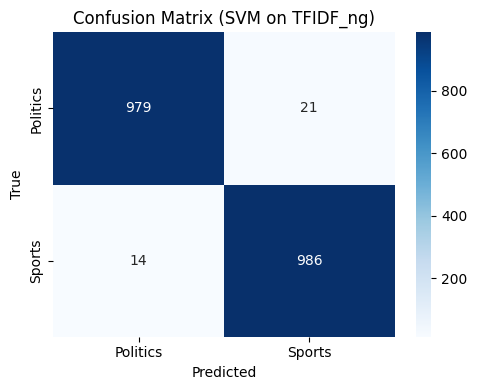

In [107]:
best_model = svm
best_model.fit(X_train_tfidf_ng, y_train)
y_pred = best_model.predict(X_test_tfidf_ng)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Politics", "Sports"],
            yticklabels=["Politics", "Sports"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (SVM on TFIDF_ng)")
plt.tight_layout()
plt.show()


**Plot the learning Curves for 3 Models**

In [108]:
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVM": LinearSVC()
}


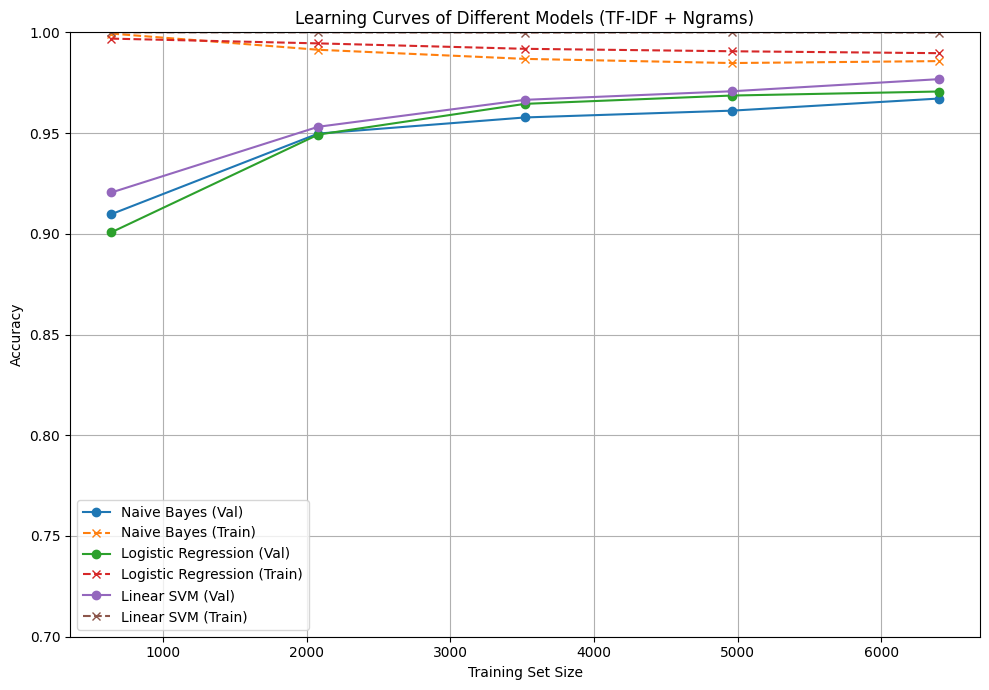

In [109]:
plt.figure(figsize=(10, 7))

train_sizes = np.linspace(0.1, 1.0, 5)

for name, model in models.items():
    train_sizes_abs, train_scores, val_scores = learning_curve(
        model,
        X_train_tfidf_ng,
        y_train,
        train_sizes=train_sizes,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)

    # Plot validation curves
    plt.plot(train_sizes_abs, val_mean, marker="o", label=f"{name} (Val)")

    # Plot Training Curves
    plt.plot(train_sizes_abs, train_mean, marker="x", linestyle="--", label=f"{name} (Train)")

plt.title("Learning Curves of Different Models (TF-IDF + Ngrams)")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.ylim(0.7, 1.0)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


**Accuracy Comparison across all feature combinations**

                 Model          Feature  Accuracy
0          Naive Bayes              BoW    0.9795
1          Naive Bayes           TF-IDF    0.9765
2          Naive Bayes  TF-IDF + Ngrams    0.9715
3  Logistic Regression              BoW    0.9820
4  Logistic Regression           TF-IDF    0.9810
5  Logistic Regression  TF-IDF + Ngrams    0.9810
6           Linear SVM              BoW    0.9740
7           Linear SVM           TF-IDF    0.9805
8           Linear SVM  TF-IDF + Ngrams    0.9825


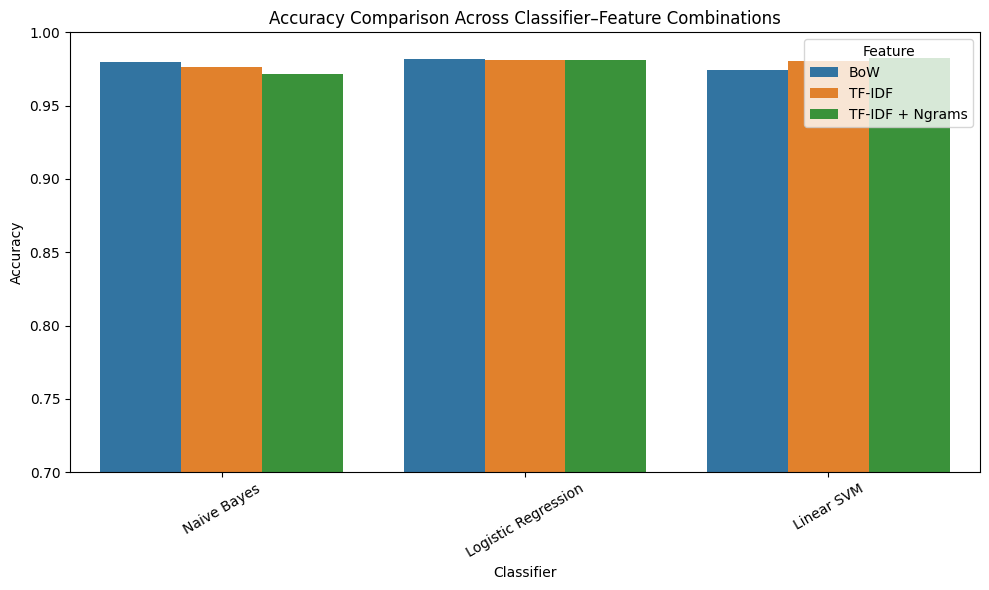

In [110]:
feature_sets = {
    "BoW": (X_train_bow, X_test_bow),
    "TF-IDF": (X_train_tfidf, X_test_tfidf),
    "TF-IDF + Ngrams": (X_train_tfidf_ng, X_test_tfidf_ng),
}

results = []

for model_name, model in models.items():
    for feat_name, (Xtr, Xte) in feature_sets.items():
        model.fit(Xtr, y_train)
        y_pred = model.predict(Xte)
        acc = accuracy_score(y_test, y_pred)

        results.append({
            "Model": model_name,
            "Feature": feat_name,
            "Accuracy": acc
        })

results_df = pd.DataFrame(results)
print(results_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x="Model", y="Accuracy", hue="Feature")
plt.title("Accuracy Comparison Across Classifier–Feature Combinations")
plt.ylim(0.7, 1.0)
plt.ylabel("Accuracy")
plt.xlabel("Classifier")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()